In [16]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import numpy as np
import copy
import math

import torch
from torch import Tensor, nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

from common.model.cnn_simple import CIFAR10ReLU
from common.const import DATASET_PATH
from common.util import *
from common.meta import MetaData
#from common.optimise import OptimiserEtaSoftmaxArmihoNorm2Base, OptimiserEtaSoftmaxArmihoNorm1Base, reduce_to_active
from common.optimise_v3 import NetLineStepProcessor
#from common.dropout_manual import DropoutManual

from torchvision.datasets import CIFAR10
from torchvision import transforms

import logging

In [17]:
logging.basicConfig(filename="log_convcrity_cifar10_epochsd_v3.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")
#                datefmt="%m/%d/%Y %I:%M:%S")


#### CIFAR10 dataset

In [18]:
# Convert from PIL to torch.Tensort
# and normalize each pixel from [0, 255] range to [0.0, 1.0]
base_transforms = transforms.ToTensor()

# An augmentation that randomly (with a probability equal to 0.5)
# flips the image horizontally
# This will prevent overfitting and make the model more robust
aug_transforms = transforms.RandomHorizontalFlip(p=0.5)

# Gather all transforms together
train_transforms = transforms.Compose([
    base_transforms,
    aug_transforms
])

train_dataset = CIFAR10(root=DATASET_PATH, train=True, download=True, transform=train_transforms)

# Note that we only use `base_transforms` for test dataset
test_dataset = CIFAR10(root=DATASET_PATH, train=False, download=True, transform=base_transforms)

Files already downloaded and verified
Files already downloaded and verified


In [19]:
BATCH_SIZE = 64 #64 #32

# `pin_memory` speed up processing if you use GPU
# `num_workers` also speed up processing since use additional process
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             num_workers=0, pin_memory=True)

In [20]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.1
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

INPUT_DIM=32*32 #*3 USING 0.299 ∙ Red + 0.587 ∙ Green + 0.114 ∙ Blue for gray-transform
OUTPUT_DIM = 10 #26  # num of classes

lb, lw = 0.005, 5.0
meta = MetaData(input_dim = INPUT_DIM, output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE, lb = 0.005, lw = 5.0, reduction='mean')

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


##### UTILS

#### Compare optimisers

In [21]:
def print_comparison(HISTORY_NORM2, HISTORY_OPTFIX, HISTORY_ADAM):
    #start_epoch, finish_epoch = 10, 20
    display.clear_output()
    fig, axes = plt.subplots(2, 1, figsize=(12, 16))
    axes[0].set_title('Loss (Cross Entropy)')
    #axes[0].set_xlim(start_epoch-1, finish_epoch)
    #axes[0].plot(HISTORY_NORM1['train_loss'][2:40], color='g', ls='dotted', alpha=.5, label='Train norm1')
    #axes[0].plot(HISTORY_NORM2['train_loss'][2:40], color='b', ls='dotted', alpha=.5, label='Train norm2')
    #axes[0].plot(HISTORY_ZHS['train_loss'][2:40], color='r', ls='dotted', alpha=.5, label='Train Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['train_loss'][2:40], color='orange', ls='dotted', alpha=.5, label='Train Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['train_loss'][2:40], color='brown', ls='dotted', alpha=.5, label='Train direct Zhang-lambda')
    axes[0].plot(HISTORY_ADAM['test_loss'], color='g', alpha=.5, label='Adam')
    axes[0].plot(HISTORY_NORM2['test_loss'], color='b', alpha=.5, label='Net-line')
    #axes[0].plot(HISTORY_ZHS['test_loss'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['test_loss'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['test_loss'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[0].plot(HISTORY_OPTFIX['test_loss'], color='grey', alpha=.5, label='SGD')
    axes[0].grid()
    axes[0].legend()
    axes[0].set_xlabel("Epoch (series of gradient descent steps)")
    axes[0].set_ylabel("Loss value")

    axes[1].set_title('Accuracy')
    #axes[1].set_xlim(10, 20)
    #axes[1].plot(HISTORY_NORM1['train_accuracy'][2:40], color='g', alpha=.5, ls='dotted', label='Train norm1')
    #axes[1].plot(HISTORY_NORM2['train_accuracy'][2:40], color='b', alpha=.5, ls='dotted', label='Train norm2')
    #axes[1].plot(HISTORY_ZHS['train_accuracy'][2:40], color='r', alpha=.5, ls='dotted', label='Train Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['train_accuracy'][2:40], color='orange', alpha=.5, ls='dotted', label='Train Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['train_accuracy'][2:40], color='brown', alpha=.5, ls='dotted', label='Train direct Zhang-lambda')
    axes[1].plot(HISTORY_ADAM['test_accuracy'], color='g', alpha=.5, label='Adam')
    axes[1].plot(HISTORY_NORM2['test_accuracy'], color='b', alpha=.5, label='Net-line')
    #axes[1].plot(HISTORY_ZHS['test_accuracy'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['test_accuracy'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['test_accuracy'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[1].plot(HISTORY_OPTFIX['test_accuracy'], color='grey', alpha=.5, label='SGD')
    axes[1].grid()
    axes[1].legend()
    axes[1].set_xlabel("Epoch (series of gradient descent steps)")
    axes[1].set_ylabel("Accuracy value")

    #fig.tight_layout()
    #fig.subplots_adjust(top=0.95)
    dummy=fig.suptitle("Comparison for the same CNN architecture for different optimisers")

    plt.show()

#### Reference CNN

In [22]:
def make_model(dropout_const = 1.0):
    
    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25*dropout_const),
        nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25*dropout_const),
        nn.Flatten(),
        nn.Linear(4096, 256),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.5*dropout_const),
        nn.Linear(256, 10)
    )

    return model

In [23]:
HISTORY_NORM2 = collections.defaultdict(list)
HISTORY_OPTFIX = collections.defaultdict(list)
HISTORY_ADAM = collections.defaultdict(list)

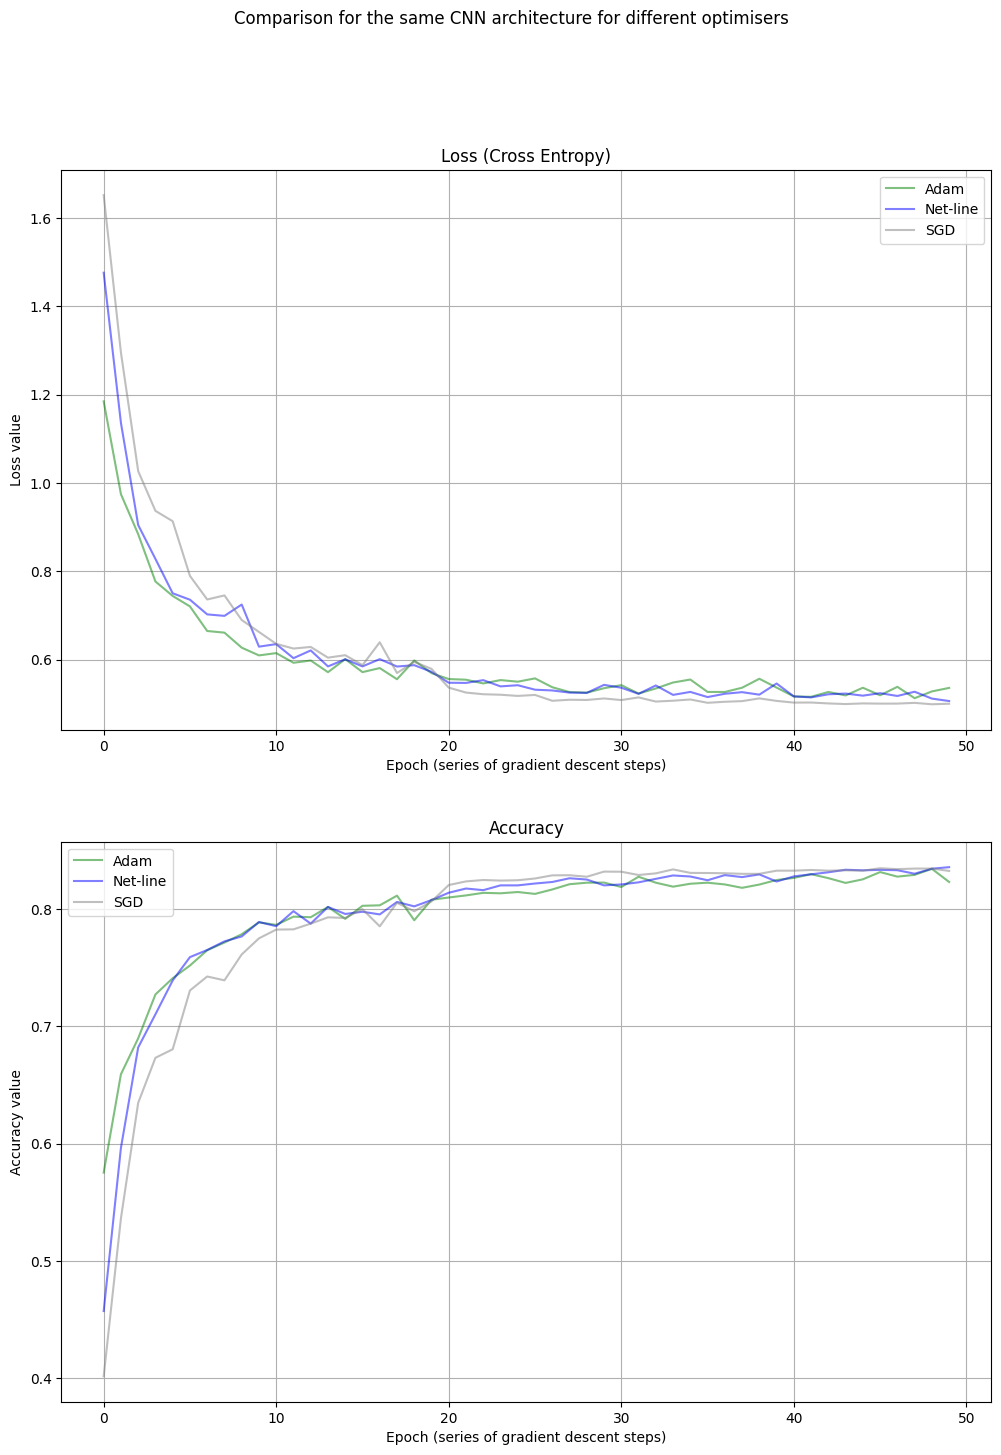

accuracy norm2=[0.45710589171974525, 0.5963375796178344, 0.6820262738853503, 0.7102906050955414, 0.7391520700636943, 0.7590565286624203, 0.7651273885350318, 0.7724920382165605, 0.776671974522293, 0.7890127388535032, 0.7854299363057324, 0.7982683121019108, 0.7876194267515924, 0.8018511146496815, 0.7958797770700637, 0.7977707006369427, 0.7954816878980892, 0.8061305732484076, 0.8023487261146497, 0.8077229299363057, 0.8139928343949044, 0.8175756369426752, 0.8161823248407644, 0.8202627388535032, 0.8202627388535032, 0.8218550955414012, 0.8231488853503185, 0.8263335987261147, 0.8252388535031847, 0.8202627388535032, 0.8210589171974523, 0.8228503184713376, 0.8258359872611465, 0.8287221337579618, 0.8278264331210191, 0.8246417197452229, 0.8290207006369427, 0.8273288216560509, 0.8296178343949044, 0.823546974522293, 0.8279259554140127, 0.8297173566878981, 0.8314092356687898, 0.8335987261146497, 0.8331011146496815, 0.8334992038216561, 0.8332006369426752, 0.8302149681528662, 0.8344944267515924, 0.835

In [24]:
def test_loop(testNet):
    test_loss_meter, test_accuracy_meter = AverageMeter(), AverageMeter(),
    for test_batch in test_dataloader:
        images, labels = test_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            logits = testNet.forward(images)

            zz_logits = np.transpose(logits.detach().cpu().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(calculate_accuracy(prediction, labels))

    return test_loss_meter.avg, test_accuracy_meter.avg

NUM_EPOCH = 50
eta_fixed = 0.01

testOptfix = make_model().to(DEVICE)
loss_fnFix = nn.CrossEntropyLoss()
optimizerFix = optim.SGD(testOptfix.parameters(), lr=eta_fixed, momentum=0.9, nesterov=True)

testNorm2S = copy.deepcopy(testOptfix)
stepProcessor = NetLineStepProcessor(testNorm2S, nn.CrossEntropyLoss(), meta, DEVICE)

testAdam = copy.deepcopy(testOptfix)
loss_adam = nn.CrossEntropyLoss()
optimizerAdam = optim.Adam(testAdam.parameters()) #, lr=eta_fixed

do_dropout, epoch_switch=False, 100
for epoch in range(NUM_EPOCH):
    loss_data = HISTORY_NORM2['test_loss']
    if len(loss_data) > 1 and ((loss_data[-2]-loss_data[-1])/loss_data[-1]) < 0.000001:
        do_dropout = True
    epoch_switch = min(epoch, epoch_switch) if do_dropout else epoch_switch

    lr = eta_fixed if epoch < 20 else eta_fixed * 0.1 if epoch < 40 else eta_fixed * 0.01

    stepProcessor.c1 = 0.0049
    stepProcessor.eta_max = 100*lr #if not do_dropout else lr
    stepProcessor.reducing_coeff = 1.0 if not do_dropout else 0.5 if epoch < 20 else 0.25
    stepProcessor.eta_min = 0.001* lr #if not do_dropout else lr
    stepProcessor.eta0 = 0.000_000_1 #0.000_000_25 #0.000_000_25-no-dropout #0.000_000_5
    stepProcessor.iter_max = 1
    stepProcessor.momentum_gradient_smoothing_coefficient = 10.0 #10.0 #10.0
    
    stepProcessor.training_mode=do_dropout
    testNorm2S.train(False)
    step_params = {"estimation_type": 'analytic-norm2'} #if not do_dropout \
        #else {"estimation_type": 'analytic-norm2', "check_additional": False} #, 'check_armiho': False

    optimizerFix.param_groups[0]['lr'] = lr
    testOptfix.train(True)

    #optimizerAdam.param_groups[0]['lr'] = lr
    testAdam.train(True)    

    train_eta2raw_plus_meter, train_eta2raw_minus_meter, train_eta2_meter, train_armiho2_meter, train_wolf2_meter\
          = AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter()

    iter=0
    for train_batch in train_dataloader:
        images, labels = train_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        pp = labels_to_softhot(labels, meta.output_dim)
        iter+=1

        logging.info("##\n --==Epoch={}, iter={}==--".format(epoch, iter))
        logging.info("####Step with net-line norm2")
        step_result = stepProcessor.step(labels, images, momentum=0.9, nesterov=True, step_params=step_params)
        train_eta2_meter.update(step_result.eta)
        train_armiho2_meter.update(step_result.ck_armiho)
        train_wolf2_meter.update(step_result.ck_wolf)
        if step_result.eta_raw > 0.0:
            train_eta2raw_plus_meter.update(step_result.eta_raw)
        else:
            train_eta2raw_minus_meter.update(step_result.eta_raw)        

        logging.info("####Step with SGD-fix, eta={}".format(optimizerFix.param_groups[0]['lr']))
        logitsOptfix = testOptfix.forward(images)
        lossOptfix = loss_fnFix(logitsOptfix, labels)
        optimizerFix.zero_grad()
        lossOptfix.backward()
        optimizerFix.step()

        logging.info("####Step with Adam-fix, eta={}".format(optimizerAdam.param_groups[0]['lr']))
        logitsAdam = testAdam.forward(images)
        lossAdam = loss_adam(logitsAdam, labels)
        optimizerAdam.zero_grad()
        lossAdam.backward()
        optimizerAdam.step()

    HISTORY_NORM2['train_eta'].append(train_eta2_meter.avg)
    HISTORY_NORM2['train_eta_raw_plus'].append(train_eta2raw_plus_meter.avg)
    HISTORY_NORM2['train_eta_raw_minus'].append(train_eta2raw_minus_meter.avg)
    HISTORY_NORM2['train_armiho'].append(train_armiho2_meter.avg)
    HISTORY_NORM2['train_wolf'].append(train_wolf2_meter.avg)

    testNorm2S.eval()
    testOptfix.eval()
    testAdam.eval()
    # testing loop
    netl, neta = test_loop(testNorm2S)
    HISTORY_NORM2['test_loss'].append(netl)
    HISTORY_NORM2['test_accuracy'].append(neta) 

    sgdl, sgda = test_loop(testOptfix)
    HISTORY_OPTFIX['test_loss'].append(sgdl)
    HISTORY_OPTFIX['test_accuracy'].append(sgda)

    adaml, adama = test_loop(testAdam)
    HISTORY_ADAM['test_loss'].append(adaml)
    HISTORY_ADAM['test_accuracy'].append(adama)    
    
    print_comparison(HISTORY_NORM2, HISTORY_OPTFIX, HISTORY_ADAM)
    print("accuracy norm2={}, \naccuracy sgd-fix={}, \naccuracy adam-fix={}, \nswitch={}, reducing_coeff={}"\
          .format(HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy'], HISTORY_ADAM['test_accuracy']\
                  , epoch_switch, stepProcessor.reducing_coeff))


In [25]:
HISTORY_NORM2['train_armiho']


[0.7425609959591692,
 0.765021724994175,
 0.7702912963032836,
 0.7534876599587628,
 0.7364889669181631,
 0.7187299269112024,
 0.6925698203648697,
 0.6710883347476844,
 0.657035740244351,
 0.9023972642762788,
 0.9042824396886134,
 0.9057564850477954,
 0.9054494627319871,
 0.9072320253557942,
 0.9062093332956886,
 0.9025163791903361,
 0.9042738332483375,
 0.9058712880120952,
 0.9090836141694429,
 0.9084172052952459,
 0.9496338233654653,
 0.9507694723508224,
 0.9524529464261692,
 0.950686776729647,
 0.9523811450195515,
 0.9524729743732457,
 0.9511910159728164,
 0.9517557972854189,
 0.9521543095789987,
 0.95380914537186,
 0.9543938315894556,
 0.9533726854734357,
 0.9543281336097823,
 0.954382041121422,
 0.9560694641588782,
 0.9560672153050193,
 0.9562127876831134,
 0.9555478664481396,
 0.9564794223720465,
 0.9567589396233873,
 0.9561928443028437,
 0.9589035581299401,
 0.9594698183491974,
 0.9579010023027833,
 0.9584260003058206,
 0.9586667448942315,
 0.9586171230768383,
 0.9601879971511823

In [26]:
HISTORY_NORM2['train_wolf']

[0.5245697280759333,
 0.5922375741164095,
 0.6171218082258484,
 0.6021256067454126,
 0.5840963286796493,
 0.5631632627462035,
 0.5335383983900079,
 0.5090526723176354,
 0.49520250173998154,
 0.8236922231365887,
 0.8259620698221067,
 0.8290702963193436,
 0.828378474059322,
 0.8309521712878899,
 0.8292848310673266,
 0.8245773652948098,
 0.827323429152669,
 0.8295160321488516,
 0.8352648072218612,
 0.83361305091263,
 0.9028628932489292,
 0.9044413922218282,
 0.9073054896671947,
 0.9041592758985607,
 0.9070925037771858,
 0.9069833538376493,
 0.9049890045270381,
 0.9062183994885712,
 0.9065623218226315,
 0.9095816771006316,
 0.9103437966383325,
 0.9085068392552728,
 0.9099327824720577,
 0.9101194523642511,
 0.9131636929106461,
 0.9130812989612576,
 0.9131860551929739,
 0.9119841655936554,
 0.9137748147775203,
 0.9139293111696148,
 0.913021413292903,
 0.9173150401841932,
 0.9184855010944522,
 0.9159013154682925,
 0.9165456630206696,
 0.9170087394619083,
 0.9167583962357798,
 0.91955318453390

In [27]:
HISTORY_NORM2['train_eta']

[0.011876064478228912,
 0.014440359353662254,
 0.018773700069291,
 0.020568232415666996,
 0.021463925047999353,
 0.020780581419883638,
 0.019410376418060538,
 0.018099383954866658,
 0.01667803795102918,
 0.010635444877973665,
 0.010989204597989733,
 0.010988845342606655,
 0.01083081570418911,
 0.010807907147462305,
 0.010763325195057164,
 0.010661175720704326,
 0.01065926055159052,
 0.010544352211703571,
 0.010511100852902132,
 0.01027271126933705,
 0.006064523708517124,
 0.006032749439961803,
 0.005951604779939572,
 0.00586738344700418,
 0.005723257479358911,
 0.005799531137658109,
 0.005759712916656691,
 0.00568946134538235,
 0.005588763824077763,
 0.00563934852044409,
 0.005605090879013581,
 0.005561923304269425,
 0.0055095394181225305,
 0.005420565736063938,
 0.005405194074722626,
 0.005420392273145342,
 0.005308916984505756,
 0.0052637087827307714,
 0.005306642589632609,
 0.0053178775805545735,
 0.005240459381931569,
 0.00516946521130288,
 0.005224826395934069,
 0.0051277322382934

In [28]:
HISTORY_NORM2['train_eta_raw_plus']

[0.011876064478228912,
 0.014440359353662254,
 0.018773700069291,
 0.020568232415666996,
 0.021463925047999353,
 0.020780581419883638,
 0.019410376418060538,
 0.018099383954866658,
 0.01667803795102918,
 0.010635444877973665,
 0.010989204597989733,
 0.010988845342606655,
 0.01083081570418911,
 0.010807907147462305,
 0.010763325195057164,
 0.010661175720704326,
 0.01065926055159052,
 0.010544352211703571,
 0.010511100852902132,
 0.01027271126933705,
 0.006064523708517124,
 0.006032749439961803,
 0.005951604779939572,
 0.00586738344700418,
 0.005723257479358911,
 0.005799531137658109,
 0.005759712916656691,
 0.00568946134538235,
 0.005588763824077763,
 0.00563934852044409,
 0.005605090879013581,
 0.005561923304269425,
 0.0055095394181225305,
 0.005420565736063938,
 0.005405194074722626,
 0.005420392273145342,
 0.005308916984505756,
 0.0052637087827307714,
 0.005306642589632609,
 0.0053178775805545735,
 0.005240459381931569,
 0.005170590102995399,
 0.005225178778011813,
 0.005127732238293

In [29]:
HISTORY_NORM2['train_eta_raw_minus']

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [30]:
print("accuracy norm2={}, \naccuracy Nesterov-fix={}"\
        .format(HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy']))

accuracy norm2=[0.45710589171974525, 0.5963375796178344, 0.6820262738853503, 0.7102906050955414, 0.7391520700636943, 0.7590565286624203, 0.7651273885350318, 0.7724920382165605, 0.776671974522293, 0.7890127388535032, 0.7854299363057324, 0.7982683121019108, 0.7876194267515924, 0.8018511146496815, 0.7958797770700637, 0.7977707006369427, 0.7954816878980892, 0.8061305732484076, 0.8023487261146497, 0.8077229299363057, 0.8139928343949044, 0.8175756369426752, 0.8161823248407644, 0.8202627388535032, 0.8202627388535032, 0.8218550955414012, 0.8231488853503185, 0.8263335987261147, 0.8252388535031847, 0.8202627388535032, 0.8210589171974523, 0.8228503184713376, 0.8258359872611465, 0.8287221337579618, 0.8278264331210191, 0.8246417197452229, 0.8290207006369427, 0.8273288216560509, 0.8296178343949044, 0.823546974522293, 0.8279259554140127, 0.8297173566878981, 0.8314092356687898, 0.8335987261146497, 0.8331011146496815, 0.8334992038216561, 0.8332006369426752, 0.8302149681528662, 0.8344944267515924, 0.835